## NSGA-II

In [1]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation
from datetime import datetime

current_time = datetime.now()
time_str = current_time.strftime("%Y_%m_%d_%H_%M_%S")

In [2]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "nsga2",
    ]
    
    run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [00:55<00:00,  1.85s/ experiment]


Execution time: 56.07


Running cross-validation experiments: 100%|██████████| 30/30 [03:48<00:00,  7.63s/ experiment]


Execution time: 229.28


Running cross-validation experiments: 100%|██████████| 30/30 [01:33<00:00,  3.12s/ experiment]


Execution time: 94.15


=========== DATASET iris ===========



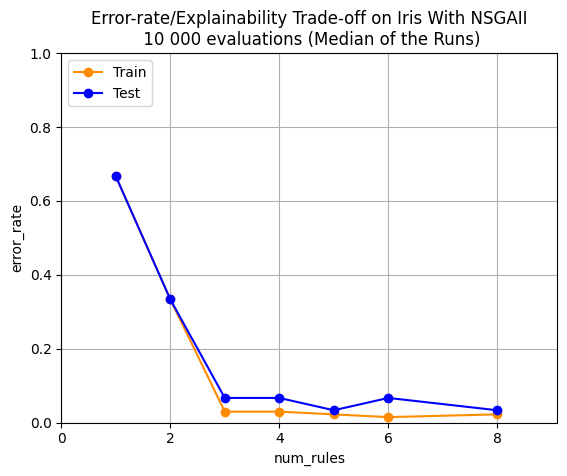

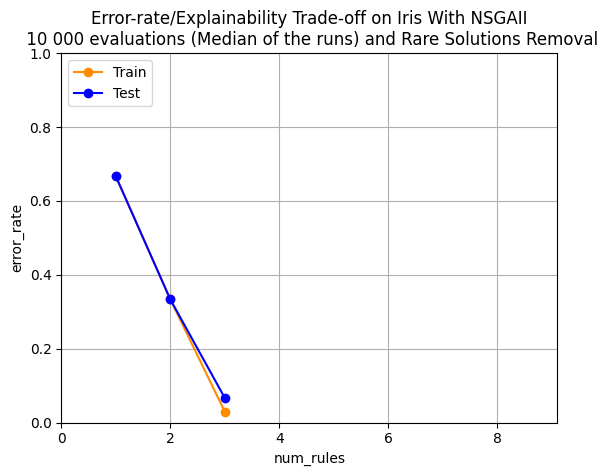

Q1:  15.200424551963806
Median :  15.888108134269714
Q3:  16.145623087882996
Average :  15.52088508605957
Std:  1.367789663292799
=========== DATASET pima ===========



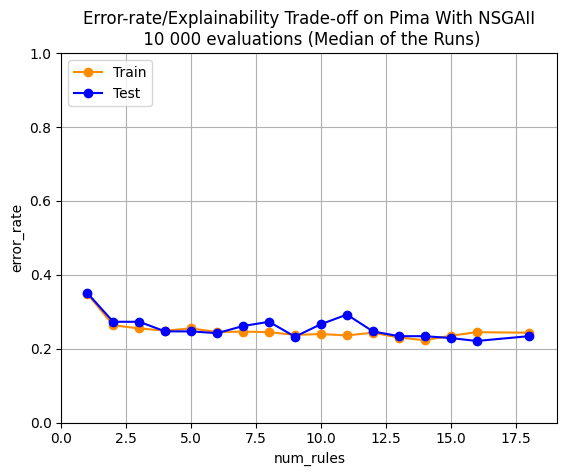

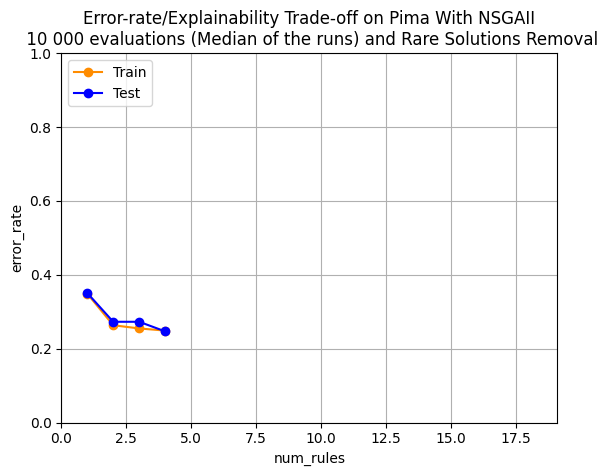

Q1:  56.59585964679718
Median :  65.17256546020508
Q3:  68.75655919313431
Average :  64.03456583023072
Std:  8.959918843046696
=========== DATASET bupa ===========



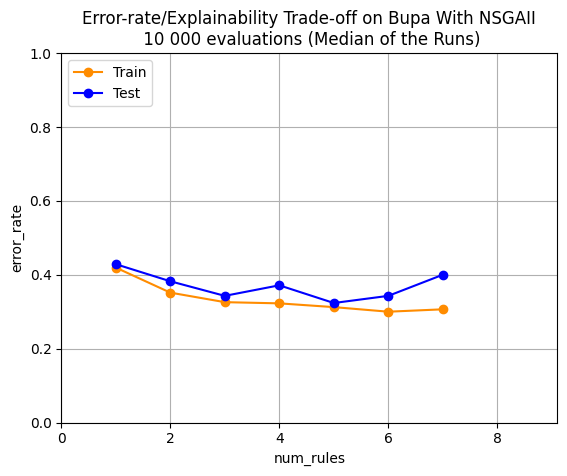

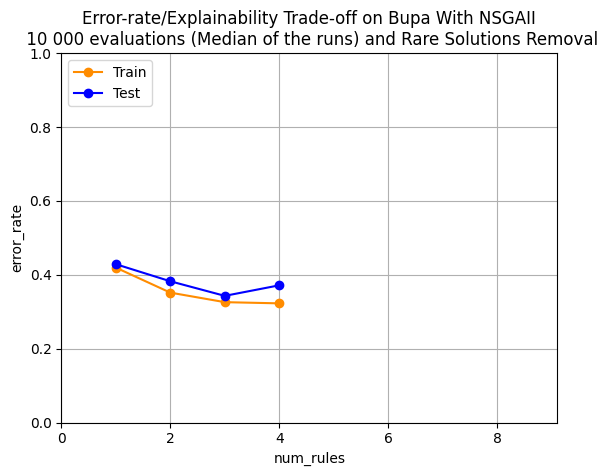

Q1:  25.404983699321747
Median :  27.343676209449768
Q3:  28.540620863437653
Average :  26.372567160924277
Std:  3.2715539258807267


In [3]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,9.1),
    "pima": (0,19.1),
    "bupa": (0,9.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]
    
    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)
        
    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()
    
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))


## MOEA/D

In [ ]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "moead",
    ]

    run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [01:06<00:00,  2.23s/ experiment]


Execution time: 67.44


Running cross-validation experiments:   0%|          | 0/30 [00:00<?, ? experiment/s]

In [ ]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,10.1),
    "pima": (0,12.1),
    "bupa": (0,11.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]

    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)

    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()

    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))